In [1]:
import pandas as pd
import numpy as np
a=pd.read_csv(r"C:\Users\pshar\Downloads\Lab Session Data(marketing_campaign).csv")
print("first 5 rows:")
print(a.head())
print("\ncloumns")
for col in a.columns:
    print(col)
print("\n feature datatype")
for col in a.columns:
    if col=="Education":
        dtype="Ordinal"
    elif col=="Year_Birth" or col=="Dt_Customer":
        dtype="Interval"
    elif col=="ID" or col=="Marital_Status" or col=="AcceptedCmp1" or col=="AcceptedCmp2" or col=="AcceptedCmp3" or col == "AcceptedCmp4" or col=="AcceptedCmp5" or col=="Complain" or col=="Response":
        dtype="Nominal"
    else:
        dtype="ratio"
    print(col,"-",dtype)

first 5 rows:
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  09/04/2012       58       635  ...                  7             0   
1  03/08/2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  02/10/2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0

In [9]:
import pandas as pd
import numpy as np
a=pd.read_csv(r"C:\Users\pshar\Downloads\Lab Session Data(marketing_campaign).csv")
def label(column):
    unique=column.unique()
    encoded=[]
    for value in column:
        num=list(unique).index(value)
        encoded.append(num)
    return encoded
def onehot(column):
    unique=column.unique()
    new=pd.DataFrame()
    for value in unique:
        temp=[]
        for item in column:
            if item==value:
                temp.append(1)
            else:
                temp.append(0)
        new[value]=temp
    return new
education=label(a["Education"])
marital=label(a["Marital_Status"])
print("label:")
print("one-hot:")
education_onehot = onehot(a["Education"])
print(education_onehot.head())

label:
one-hot:
   Graduation  PhD  Master  Basic  2n Cycle
0           1    0       0      0         0
1           1    0       0      0         0
2           1    0       0      0         0
3           1    0       0      0         0
4           0    1       0      0         0


In [10]:
import pandas as pd
data=pd.read_csv(r"C:\Users\pshar\Downloads\Lab Session Data(marketing_campaign).csv")
def label_encode(column):
    unique = column.unique()
    encoded = []
    for value in column:
        encoded.append(list(unique).index(value))
    return encoded
def one_hot_encode(column):
    unique=column.unique()
    new_data=pd.DataFrame()
    for value in unique:
        temp=[]
        for item in column:
            if item==value:
                temp.append(1)
            else:
                temp.append(0)
        new_data[value]=temp
    return new_data
print("Original Dataset Shape")
print(data.shape)
data["Education"]=label_encode(data["Education"])
marital=one_hot_encode(data["Marital_Status"])
data=data.drop("Marital_Status",axis=1)
data=pd.concat([data, marital],axis=1)
print("\nNew Dataset Shape")
print(data.shape)
print("\nUpdated Dataset")
print(data.head())

Original Dataset Shape
(2240, 29)

New Dataset Shape
(2240, 36)

Updated Dataset
     ID  Year_Birth  Education   Income  Kidhome  Teenhome Dt_Customer  \
0  5524        1957          0  58138.0        0         0  09/04/2012   
1  2174        1954          0  46344.0        1         1  03/08/2014   
2  4141        1965          0  71613.0        0         0  21-08-2013   
3  6182        1984          0  26646.0        1         0  02/10/2014   
4  5324        1981          1  58293.0        1         0  19-01-2014   

   Recency  MntWines  MntFruits  ...  Z_Revenue  Response  Single  Together  \
0       58       635         88  ...         11         1       1         0   
1       38        11          1  ...         11         0       1         0   
2       26       426         49  ...         11         0       0         1   
3       26        11          4  ...         11         0       0         1   
4       94       173         43  ...         11         0       0         0   


In [12]:
import pandas as pd
data=pd.read_csv(r"C:\Users\pshar\Downloads\Lab Session Data(marketing_campaign).csv")
def minkowski_distance(a, b, p):
    distance=0
    for i in range(len(a)):
        distance=distance+abs(a[i]-b[i]) ** p
    distance=distance**(1/p)
    return distance
vector1=data.loc[0, ["Income","MntWines","MntFruits"]]
vector2=data.loc[1, ["Income","MntWines","MntFruits"]]
manhattan=minkowski_distance(vector1, vector2, 1)
euclidean=minkowski_distance(vector1, vector2, 2)
print("Manhattan Distance")
print(manhattan)
print("\nEuclidean Distance")
print(euclidean)

Manhattan Distance
12505.0

Euclidean Distance
11810.816271536865


C:\Users\pshar\AppData\Local\Temp\ipykernel_3216\3428520642.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  distance=distance+abs(a[i]-b[i]) ** p


C:\Users\pshar\AppData\Local\Temp\ipykernel_3216\2123641636.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  distance=distance + abs(a[i] - b[i]) ** p


p = 1 Distance = 12505.0
p = 2 Distance = 11810.816271536865
p = 3 Distance = 11794.583800160563
p = 4 Distance = 11794.023113078529
p = 5 Distance = 11794.000977982898
p = 6 Distance = 11794.000043117523
p = 7 Distance = 11793.999999997033
p = 8 Distance = 11794.00000000001
p = 9 Distance = 11793.999999999995
p = 10 Distance = 11794.000000000005


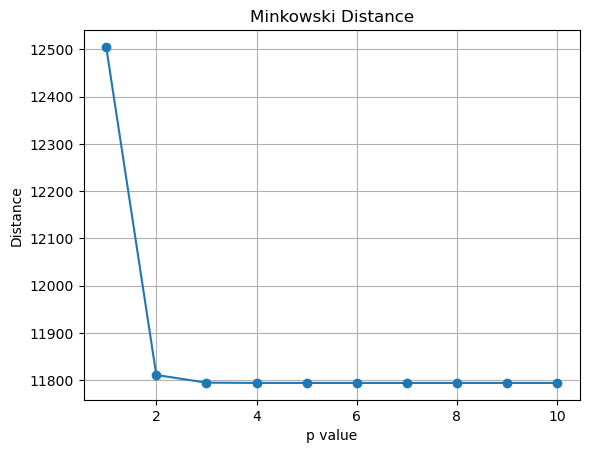

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
data=pd.read_csv(r"C:\Users\pshar\Downloads\Lab Session Data(marketing_campaign).csv")
def minkowski_distance(a, b, p):
    distance=0
    for i in range(len(a)):
        distance=distance+abs(a[i]-b[i]) ** p
    distance=distance ** (1/p)
    return distance
vector1=data.loc[0, ["Income", "MntWines", "MntFruits"]]
vector2=data.loc[1, ["Income", "MntWines", "MntFruits"]]
p_values=[]
distances=[]
for p in range(1, 11):
    d=minkowski_distance(vector1,vector2,p)
    p_values.append(p)
    distances.append(d)
    print("p =",p,"Distance =", d)
plt.plot(p_values,distances,marker="o")
plt.title("Minkowski Distance")
plt.xlabel("p value")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

In [14]:
import pandas as pd
from scipy.spatial.distance import minkowski
data=pd.read_csv(r"C:\Users\pshar\Downloads\Lab Session Data(marketing_campaign).csv")
def minkowski_distance(a, b, p):
    distance=0
    for i in range(len(a)):
        distance=distance+abs(a[i]-b[i]) ** p
    distance=distance ** (1/p)
    return distance
vector1=data.loc[0,["Income","MntWines","MntFruits"]]
vector2=data.loc[1,["Income","MntWines","MntFruits"]]
p=2
my_distance=minkowski_distance(vector1,vector2,p)
scipy_distance=minkowski(vector1,vector2,p)
print("My Distance")
print(my_distance)
print("\nScipy Distance")
print(scipy_distance)

My Distance
11810.816271536865

Scipy Distance
11810.816271536865


C:\Users\pshar\AppData\Local\Temp\ipykernel_3216\3227245345.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  distance=distance+abs(a[i]-b[i]) ** p


In [15]:
import pandas as pd
import numpy as np
data=pd.read_csv(r"C:\Users\pshar\Downloads\Lab Session Data(marketing_campaign).csv")
def dot_product(a,b):
    result=0
    for i in range(len(a)):
        result=result+(a[i]*b[i])
    return result
def euclidean_norm(a):
    total=0
    for i in range(len(a)):
        total=total+(a[i] ** 2)
    return total ** 0.5
vector1 = data.loc[0, ["Income","MntWines","MntFruits"]]
vector2 = data.loc[1, ["Income","MntWines","MntFruits"]]
my_dot = dot_product(vector1, vector2)
my_norm1 = euclidean_norm(vector1)
my_norm2 = euclidean_norm(vector2)
numpy_dot = np.dot(vector1, vector2)
numpy_norm1 = np.linalg.norm(vector1)
numpy_norm2 = np.linalg.norm(vector2)
print(my_dot)
print(numpy_dot)
print(my_norm1)
print(numpy_norm1)
print(my_norm2)
print(numpy_norm2)

2694354545.0
2694354545.0
58141.53431927988
58141.53431927988
46344.001316243724
46344.001316243724


C:\Users\pshar\AppData\Local\Temp\ipykernel_3216\891523092.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  result=result+(a[i]*b[i])
C:\Users\pshar\AppData\Local\Temp\ipykernel_3216\891523092.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total=total+(a[i] ** 2)


In [16]:
import pandas as pd
data=pd.read_csv(r"C:\Users\pshar\Downloads\Lab Session Data(marketing_campaign).csv")
data=data.select_dtypes(include="number")
def find_mean(column):
    total = 0
    for value in column:
        total = total + value
    mean = total / len(column)
    return mean
def find_variance(column):
    mean=find_mean(column)
    total=0
    for value in column:
        total = total + (value - mean) ** 2
    variance = total / len(column)
    return variance
def find_std(column):
    variance = find_variance(column)
    std = variance**0.5
    return std
for col in data.columns:
    mean = find_mean(data[col])
    variance = find_variance(data[col])
    std = find_std(data[col])
    print("\nColumn :", col)
    print("Mean :", mean)
    print("Variance :", variance)
    print("Standard Deviation :", std)


Column : ID
Mean : 5592.159821428571
Variance : 10536109.703921402
Standard Deviation : 3245.9374152810465

Column : Year_Birth
Mean : 1968.8058035714287
Variance : 143.5538056042729
Standard Deviation : 11.98139414276456

Column : Income
Mean : nan
Variance : nan
Standard Deviation : nan

Column : Kidhome
Mean : 0.44419642857142855
Variance : 0.28974310427295247
Standard Deviation : 0.5382779061720372

Column : Teenhome
Mean : 0.50625
Variance : 0.296389508928571
Standard Deviation : 0.5444166684889167

Column : Recency
Mean : 49.109375
Variance : 838.4491978236607
Standard Deviation : 28.955987253479385

Column : MntWines
Mean : 303.9357142857143
Variance : 113247.2253316325
Standard Deviation : 336.5222508715174

Column : MntFruits
Mean : 26.302232142857143
Variance : 1581.219816446118
Standard Deviation : 39.76455477490121

Column : MntMeatProducts
Mean : 166.95
Variance : 50924.685000000325
Standard Deviation : 225.66498399175785

Column : MntFishProducts
Mean : 37.52544642857143

In [18]:
import pandas as pd
import numpy as np
data=pd.read_csv(r"C:\Users\pshar\Downloads\Lab Session Data(marketing_campaign).csv")
data = data.select_dtypes(include="number")
def find_mean(column):
    total = 0
    for value in column:
        total = total + value
    return total / len(column)
def find_std(column):
    mean = find_mean(column)
    total = 0
    for value in column:
        total = total + (value - mean) ** 2
    variance = total / len(column)
    return variance ** 0.5
for col in data.columns:
    my_mean = find_mean(data[col])
    numpy_mean = np.mean(data[col])
    my_std = find_std(data[col])
    numpy_std = np.std(data[col])
    print("\nColumn:", col)
    print("My Mean:", my_mean)
    print("Numpy Mean:", numpy_mean)
    print("My Std:", my_std)
    print("Numpy Std:", numpy_std)


Column: ID
My Mean: 5592.159821428571
Numpy Mean: 5592.159821428571
My Std: 3245.9374152810465
Numpy Std: 3245.9374152810465

Column: Year_Birth
My Mean: 1968.8058035714287
Numpy Mean: 1968.8058035714287
My Std: 11.98139414276456
Numpy Std: 11.98139414276456

Column: Income
My Mean: nan
Numpy Mean: 52247.25135379061
My Std: nan
Numpy Std: 25167.39617416297

Column: Kidhome
My Mean: 0.44419642857142855
Numpy Mean: 0.44419642857142855
My Std: 0.5382779061720372
Numpy Std: 0.5382779061720372

Column: Teenhome
My Mean: 0.50625
Numpy Mean: 0.50625
My Std: 0.5444166684889167
Numpy Std: 0.5444166684889167

Column: Recency
My Mean: 49.109375
Numpy Mean: 49.109375
My Std: 28.955987253479385
Numpy Std: 28.955987253479385

Column: MntWines
My Mean: 303.9357142857143
Numpy Mean: 303.9357142857143
My Std: 336.5222508715174
Numpy Std: 336.5222508715174

Column: MntFruits
My Mean: 26.302232142857143
Numpy Mean: 26.302232142857143
My Std: 39.76455477490121
Numpy Std: 39.76455477490121

Column: MntMea

Mean: 52247.25135379061
Variance: 633397830.1872728


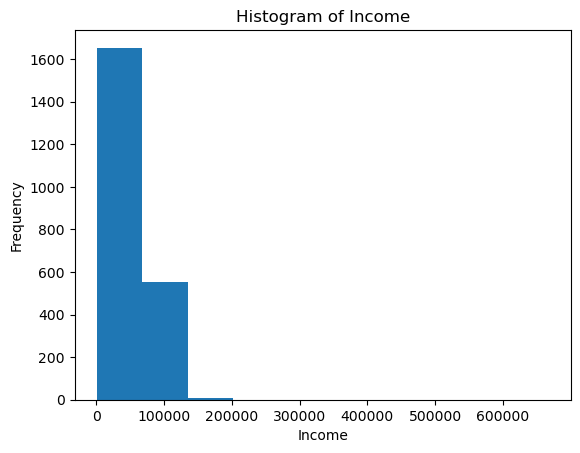

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
data=pd.read_csv(r"C:\Users\pshar\Downloads\Lab Session Data(marketing_campaign).csv")
income = data["Income"]
mean = np.mean(income)
variance = np.var(income)
print("Mean:", mean)
print("Variance:", variance)
plt.hist(income, bins=10)
plt.title("Histogram of Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

In [19]:
import pandas as pd
import numpy as np
data = pd.read_csv(r"C:\Users\pshar\Downloads\Lab Session Data(marketing_campaign).csv")
data = data.select_dtypes(include=np.number)
data = data.dropna()
X = data.values
def distance(a, b):
    s=0
    for i in range(len(a)):
        s+=(a[i] - b[i]) ** 2
    return s ** 0.5
def kmeans(X, k):
    centroids = X[:k].copy()
    while True:
        clusters=[]
        for point in X:
            d=[]
            for c in centroids:
                d.append(distance(point,c))
            clusters.append(np.argmin(d))
        clusters=np.array(clusters)
        new_centroids=[]
        for i in range(k):
            points = X[clusters==i]
            if len(points)==0:
                new_centroids.append(centroids[i])
            else:
                new_centroids.append(points.mean(axis=0))
        new_centroids = np.array(new_centroids)
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return clusters, centroids
k = 3
labels, centers = kmeans(X, k)
print("Cluster Labels:")
print(labels)
print("\nCentroids:")
print(centers)

Cluster Labels:
[0 0 2 ... 0 2 0]

Centroids:
[[5.54909136e+03 1.96533827e+03 5.56852568e+04 3.30864198e-01
  8.23456790e-01 4.93111111e+01 3.47049383e+02 2.29259259e+01
  1.24369136e+02 3.16456790e+01 2.19308642e+01 4.97234568e+01
  3.06913580e+00 5.07530864e+00 2.68148148e+00 6.72839506e+00
  5.40493827e+00 5.80246914e-02 1.00000000e-01 1.11111111e-02
  2.46913580e-02 1.72839506e-02 7.40740741e-03 3.00000000e+00
  1.10000000e+01 1.01234568e-01]
 [5.58414815e+03 1.97283871e+03 2.98794719e+04 7.95698925e-01
  3.47670251e-01 4.87718041e+01 3.90107527e+01 6.44563919e+00
  2.79820789e+01 9.52090800e+00 6.36200717e+00 1.91612903e+01
  2.21146953e+00 2.28434886e+00 5.93787336e-01 3.18996416e+00
  6.83632019e+00 8.60215054e-02 5.97371565e-03 0.00000000e+00
  1.19474313e-03 0.00000000e+00 1.55316607e-02 3.00000000e+00
  1.10000000e+01 1.18279570e-01]
 [5.65043058e+03 1.96786643e+03 8.02561213e+04 7.90861160e-02
  2.84710018e-01 4.89420035e+01 6.36768014e+02 6.05272408e+01
  4.32166960e+02 8.7